In [1]:
### PATHS ###
import sys
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))  # for notebooks/ subfolder
                                                                      # no-op for root notebooks

from paths import DIABETES_CSV, FIG_DIR, ART_DIR, MODEL_DIR

# Predicting 30-Day Hospital Readmission for Diabetic Patients

## End-to-End Machine Learning Pipeline -- Data Science Capstone

**Business Problem:** Under the CMS Hospital Readmissions Reduction Program (HRRP), hospitals face Medicare payment reductions of up to 3% for excess 30-day readmissions. This project builds a classification model to predict which diabetic inpatients are at highest risk of readmission within 30 days, enabling targeted transitional care interventions.

**Dataset:** Diabetes 130-US Hospitals (1999-2008) -- 101,766 encounters x 50 features  
**Source:** UCI Machine Learning Repository (Strack et al., 2014)  
**Methodology:** CRISP-DM with scikit-learn Pipeline  
**Target:** Binary -- readmitted within 30 days (yes/no)

---

### Key Findings

**Model:** XGBoost (tuned) -- learning_rate=0.03, max_depth=4, n_estimators=300
**Test-Set Performance:** AUC 0.693, Recall 0.621, Precision 0.118, F1 0.199
**Both success targets met:** AUC > 0.65 and Recall > 0.50 on held-out data

**Top 3 Risk Factors (SHAP):**
1. Length of stay -- shorter stays associated with higher readmission risk
2. Prior inpatient visits -- each additional prior hospitalization substantially increases risk
3. Discharge disposition -- discharge to SNF or rehab facilities associated with higher risk vs. home

**Business Impact:** At the recommended operating threshold (0.30), the model catches 92% of readmissions and generates approximately $4.6 million in annual net benefit for a 10,000-discharge hospital, after accounting for $500/patient intervention costs against $13,000/readmission penalty savings.

**Key Insight:** XGBoost started as the worst baseline model (AUC 0.679) but became the best after tuning (AUC 0.703) -- the largest improvement of any model (+0.024). The EDA hypothesis that `has_A1c_measured` would be a top predictor was not confirmed in multivariate modeling, demonstrating that univariate associations do not always survive when features compete in an ensemble.

---

## Phase 1: Data Acquisition and Initial Profiling

### 1.1 Setup and Data Loading


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color palette consistent with the project
COLORS = {
    'primary': '#1B2A4A',
    'steel': '#4A7FB5',
    'teal': '#2AA198',
    'orange': '#E67E22',
    'red': '#E74C3C',
    'green': '#2ECC71',
    'gold': '#D4A017'
}

print("Environment ready.")


Environment ready.


In [3]:
# Load the dataset
# Option 1: From CSV (download from UCI and place in Data/)
DATA_PATH = './Data/diabetic_data.csv'

# Option 2: From UCI repo package (uncomment if preferred)
# from ucimlrepo import fetch_ucirepo
# ds = fetch_ucirepo(id=296)
# df = ds.data.original
# df.to_csv(DATA_PATH, index=False)

try:
	df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
	# Notebook is in ./notebooks, so Data is one level up
	DATA_PATH = '../Data/diabetic_data.csv'
	df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Dataset loaded: 101,766 rows x 50 columns
Memory usage: 230.9 MB


### 1.2 Schema Overview

Before any cleaning, understand what each column contains: its data type, how many unique values it has, and how much data is missing.


In [4]:
# Build a comprehensive column profile
profile = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique(),
    'sample_value': df.iloc[0]
})

# The dataset uses '?' for missing values in many columns -- count those too
question_marks = df.apply(lambda col: (col == '?').sum() if col.dtype == 'object' else 0)
profile['question_marks'] = question_marks
profile['effective_missing_pct'] = ((profile['null_count'] + profile['question_marks']) / len(df) * 100).round(2)

# Sort by effective missing percentage descending
profile = profile.sort_values('effective_missing_pct', ascending=False)

print(f"{'Column':<30} {'Type':<10} {'Unique':>7} {'Nulls':>7} {'?-marks':>8} {'Eff. Missing %':>15}")
print("=" * 80)
for col, row in profile.iterrows():
    print(f"{col:<30} {str(row['dtype']):<10} {row['unique']:>7} {row['null_count']:>7} {row['question_marks']:>8} {row['effective_missing_pct']:>14.1f}%")


Column                         Type        Unique   Nulls  ?-marks  Eff. Missing %
max_glu_serum                  str              3   96420        0           94.8%
A1Cresult                      str              3   84748        0           83.3%
race                           str              6       0        0            0.0%
gender                         str              3       0        0            0.0%
age                            str             10       0        0            0.0%
weight                         str             10       0        0            0.0%
admission_type_id              int64            8       0        0            0.0%
discharge_disposition_id       int64           26       0        0            0.0%
admission_source_id            int64           17       0        0            0.0%
time_in_hospital               int64           14       0        0            0.0%
payer_code                     str             18       0        0            0.0%
medi

**Key observations from the schema:**
- The dataset uses `?` instead of NaN for missing categorical values -- these must be handled during cleaning
- `weight` is expected to be ~97% missing and will need to be dropped
- `payer_code` and `medical_specialty` will have significant missing data
- The diagnosis columns (`diag_1`, `diag_2`, `diag_3`) contain ICD-9 codes as strings with ~700 unique values each
- 23 medication columns use categorical values: "No", "Steady", "Up", "Down"
- Numeric IDs (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) are actually categorical codes that map to labels via `IDs_mapping.csv`


### 1.3 Target Variable Distribution

The `readmitted` column has three values: `<30` (readmitted within 30 days), `>30` (readmitted after 30 days), and `NO` (not readmitted). For the binary classification task, we will binarize to `<30 = 1, else = 0`.


In [5]:
# Raw target distribution
print("=== Raw Target Distribution ===")
raw_dist = df['readmitted'].value_counts()
raw_pct = df['readmitted'].value_counts(normalize=True) * 100
for val in ['NO', '>30', '<30']:
    if val in raw_dist.index:
        print(f"  {val:>5}: {raw_dist[val]:>10,}  ({raw_pct[val]:.1f}%)")

# Binarize for analysis preview
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print(f"\n=== Binary Target (readmit within 30 days) ===")
print(f"  Not readmitted <30: {(df['readmit_30'] == 0).sum():,} ({(df['readmit_30'] == 0).mean()*100:.1f}%)")
print(f"  Readmitted <30:     {(df['readmit_30'] == 1).sum():,} ({(df['readmit_30'] == 1).mean()*100:.1f}%)")
print(f"  Imbalance ratio:    {(df['readmit_30'] == 0).sum() / max((df['readmit_30'] == 1).sum(), 1):.1f}:1")


=== Raw Target Distribution ===
     NO:     54,864  (53.9%)
    >30:     35,545  (34.9%)
    <30:     11,357  (11.2%)

=== Binary Target (readmit within 30 days) ===
  Not readmitted <30: 90,409 (88.8%)
  Readmitted <30:     11,357 (11.2%)
  Imbalance ratio:    8.0:1


FileNotFoundError: [Errno 2] No such file or directory: './figures/target_distribution.png'

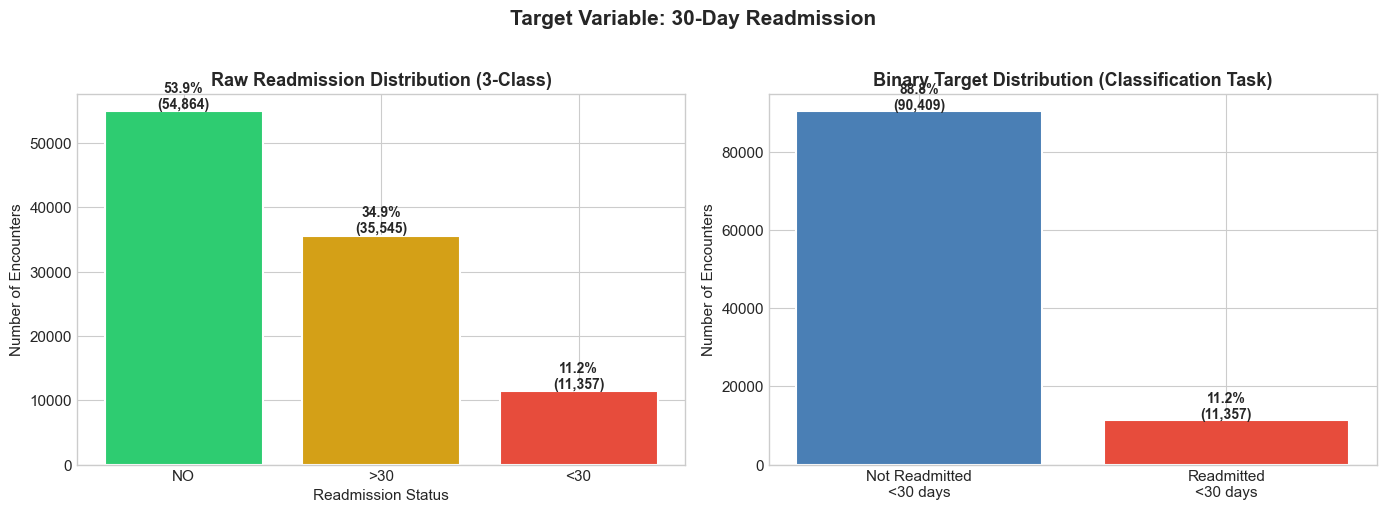

In [6]:
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw 3-class distribution
colors_3 = [COLORS['green'], COLORS['gold'], COLORS['red']]
raw_counts = df['readmitted'].value_counts().reindex(['NO', '>30', '<30'])
bars = ax1.bar(raw_counts.index, raw_counts.values, color=colors_3, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, raw_counts.values):
    pct = val / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
             f'{pct:.1f}%\n({val:,})', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Raw Readmission Distribution (3-Class)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Number of Encounters')
ax1.set_xlabel('Readmission Status')

# Binary distribution
colors_2 = [COLORS['steel'], COLORS['red']]
bin_counts = df['readmit_30'].value_counts().sort_index()
labels = ['Not Readmitted\n<30 days', 'Readmitted\n<30 days']
bars2 = ax2.bar(labels, bin_counts.values, color=colors_2, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, bin_counts.values):
    pct = val / len(df) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
             f'{pct:.1f}%\n({val:,})', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Binary Target Distribution (Classification Task)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Number of Encounters')

plt.suptitle('Target Variable: 30-Day Readmission', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance: ~{(df['readmit_30']==0).sum() // max((df['readmit_30']==1).sum(),1)}:1 -- will require SMOTE, class_weight, or threshold tuning.")


The heavy class imbalance (~89% negative, ~11% positive) is expected for this dataset and consistent with the literature. This imbalance ratio will require explicit handling during modeling -- either through SMOTE oversampling, `class_weight='balanced'`, or `scale_pos_weight` for XGBoost. The primary evaluation metric will be ROC-AUC rather than accuracy, since a naive majority-class classifier would achieve ~89% accuracy while catching zero readmissions.

### 1.4 Missing Data Analysis

The dataset encodes missing values as `?` in string columns. This section quantifies the true extent of missingness across all features.


In [ ]:
# Replace '?' with NaN for proper missing-data analysis
df_missing = df.replace('?', np.nan)

# Calculate effective missing rates
missing_summary = pd.DataFrame({
    'missing_count': df_missing.isnull().sum(),
    'missing_pct': (df_missing.isnull().sum() / len(df_missing) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

# Show only columns with any missing data
has_missing = missing_summary[missing_summary['missing_count'] > 0]

print(f"Columns with missing data: {len(has_missing)} of {len(df.columns)}")
print(f"\n{'Column':<30} {'Missing Count':>15} {'Missing %':>12}")
print("=" * 60)
for col, row in has_missing.iterrows():
    flag = " *** DROP" if row['missing_pct'] > 50 else " ** IMPUTE" if row['missing_pct'] > 5 else ""
    print(f"{col:<30} {row['missing_count']:>15,} {row['missing_pct']:>11.1f}%{flag}")


In [ ]:
# Visualize missing data for columns with >0% missing
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = has_missing.head(15)  # Top 15 by missingness
colors = [COLORS['red'] if pct > 50 else COLORS['orange'] if pct > 20 else COLORS['steel'] 
          for pct in plot_data['missing_pct']]

bars = ax.barh(range(len(plot_data)), plot_data['missing_pct'], color=colors, edgecolor='white')
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('% Missing', fontsize=12)
ax.set_title('Missing Data by Column (Top 15)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Threshold lines
ax.axvline(x=50, color=COLORS['red'], linestyle='--', alpha=0.7, label='Drop threshold (50%)')
ax.axvline(x=5, color=COLORS['orange'], linestyle='--', alpha=0.7, label='Imputation needed (5%)')
ax.legend(loc='lower right')

for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row['missing_pct'] + 0.5, i, f"{row['missing_pct']:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/missing_data.png', dpi=150, bbox_inches='tight')
plt.show()


**Missing data decisions (to be applied during cleaning):**
- **Drop:** `weight` (~97% missing) -- not recoverable. `payer_code` (~40% missing, not clinically relevant to readmission prediction)
- **Impute/categorize:** `medical_specialty`, `race` -- create "Unknown" category
- **Investigate:** `diag_1/2/3` -- small number of missing diagnoses, may need "Unknown" category
- The `?` sentinel value will be globally replaced with NaN before any processing


### 1.5 Numeric Feature Distributions

In [ ]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove IDs and the derived binary target from the profiling view
exclude = ['encounter_id', 'patient_nbr', 'readmit_30']
numeric_features = [c for c in numeric_cols if c not in exclude]

print(f"Numeric features ({len(numeric_features)}):")
for c in numeric_features:
    stats = df[c].describe()
    print(f"  {c:<30} min={stats['min']:>8.1f}  median={stats['50%']:>8.1f}  max={stats['max']:>8.1f}  std={stats['std']:>8.2f}")


In [ ]:
# Distribution plots for numeric features
n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    ax = axes[idx]
    data = df[col].dropna()
    
    ax.hist(data, bins=40, color=COLORS['steel'], alpha=0.7, edgecolor='white', density=True)
    try:
        data.plot.kde(ax=ax, color=COLORS['red'], linewidth=1.5)
    except Exception:
        pass
    
    skew = data.skew()
    ax.set_title(f'{col}\n(skew: {skew:.2f})', fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Key numeric observations:**
- `time_in_hospital`: ranges 1-14 days (by dataset design). Right-skewed -- most stays are short.
- `num_lab_procedures`, `num_medications`, `num_procedures`: count variables with right-skew. Potential for engineering (e.g., procedures per day).
- `number_inpatient`: prior inpatient visits in the past year. Heavily right-skewed -- most patients have 0, but some have many. This is a known strong predictor of readmission.
- `number_outpatient`, `number_emergency`: similar prior-utilization features. Will be combined into `total_visits_prior_year` during feature engineering.
- `number_diagnoses`: count of diagnoses. Proxy for patient complexity.


### 1.6 Categorical Feature Distributions

In [ ]:
# Key categorical columns to profile
cat_cols_to_profile = ['race', 'gender', 'age', 'admission_type_id', 
                       'discharge_disposition_id', 'admission_source_id',
                       'A1Cresult', 'max_glu_serum', 'change', 'diabetesMed']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_to_profile):
    ax = axes[idx]
    
    # Get value counts, replacing ? with 'Missing'
    data = df[col].replace('?', 'Missing')
    counts = data.value_counts().head(10)
    
    bars = ax.barh(range(len(counts)), counts.values, color=COLORS['steel'], edgecolor='white')
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels([str(v)[:20] for v in counts.index], fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    
    # Add count labels
    for i, v in enumerate(counts.values):
        ax.text(v + counts.max()*0.01, i, f'{v:,}', va='center', fontsize=7)

plt.suptitle('Key Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Key categorical observations:**
- `age`: 10-year buckets. Peak in [70-80) and [60-70) -- expected for a diabetic Medicare population.
- `race`: Predominantly Caucasian. Small "?" (missing) category needs recoding.
- `gender`: Roughly balanced. A small "Unknown/Invalid" category exists.
- `A1Cresult`: Most encounters show "None" (HbA1c not measured). This is the key finding from the Strack et al. paper -- patients whose HbA1c was measured had lower readmission rates.
- `discharge_disposition_id`: Numeric codes. Must reference `IDs_mapping.csv` to decode. Codes 11, 19, 20, 21 = "Expired" -- these patients must be removed since they cannot be readmitted.
- `change` and `diabetesMed`: Medication management indicators. "Ch" = medication changed during stay.


### 1.7 Duplicate Patient Encounters

A single patient can have multiple encounters in the dataset. This creates a data leakage risk -- if the same patient appears in both train and test sets, the model may learn patient-specific patterns rather than generalizable readmission risk factors.


In [ ]:
# Check for duplicate patients
total_encounters = len(df)
unique_patients = df['patient_nbr'].nunique()
multi_encounter = df.groupby('patient_nbr').size()
patients_with_multiple = (multi_encounter > 1).sum()

print(f"Total encounters:          {total_encounters:,}")
print(f"Unique patients:           {unique_patients:,}")
print(f"Patients with 1 encounter: {(multi_encounter == 1).sum():,}")
print(f"Patients with 2+ encounters: {patients_with_multiple:,}")
print(f"Max encounters per patient:  {multi_encounter.max()}")
print(f"\nRows to remove if keeping 1 per patient: ~{total_encounters - unique_patients:,}")

# Distribution of encounters per patient
fig, ax = plt.subplots(figsize=(10, 5))
encounter_dist = multi_encounter.value_counts().sort_index().head(15)
ax.bar(encounter_dist.index, encounter_dist.values, color=COLORS['steel'], edgecolor='white')
ax.set_xlabel('Number of Encounters per Patient', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Distribution of Encounters per Patient', fontsize=14, fontweight='bold')
for i, (x, y) in enumerate(zip(encounter_dist.index, encounter_dist.values)):
    if i < 8:
        ax.text(x, y + encounter_dist.max()*0.01, f'{y:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/encounters_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()


**Decision:** During cleaning (Phase 3), keep only one encounter per patient -- the one with the longest `time_in_hospital` -- to avoid data leakage from correlated outcomes. This follows the approach used by multiple published analyses of this dataset.

### 1.8 Medication Column Survey

23 columns represent individual medications. Each has categorical values: "No" (not prescribed), "Steady" (dose unchanged), "Up" (dose increased), "Down" (dose decreased).


In [ ]:
# Survey medication columns
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

print(f"{'Medication':<30} {'No':>8} {'Steady':>8} {'Up':>8} {'Down':>8} {'Change %':>10}")
print("=" * 75)
for col in med_cols:
    if col in df.columns:
        counts = df[col].value_counts()
        no = counts.get('No', 0)
        steady = counts.get('Steady', 0)
        up = counts.get('Up', 0)
        down = counts.get('Down', 0)
        total = len(df)
        change_pct = (up + down) / total * 100
        print(f"{col:<30} {no:>8,} {steady:>8,} {up:>8,} {down:>8,} {change_pct:>9.1f}%")

# How many medications had dosage changes?
print(f"\n--- Feature engineering preview ---")
change_count = df[med_cols].apply(lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1)
print(f"medication_change_count: min={change_count.min()}, median={change_count.median():.0f}, max={change_count.max()}")
print(f"Patients with 0 changes: {(change_count == 0).sum():,} ({(change_count == 0).mean()*100:.1f}%)")
print(f"Patients with 1+ changes: {(change_count > 0).sum():,} ({(change_count > 0).mean()*100:.1f}%)")


**Key observations:**
- `insulin` is the most actively managed medication -- significant proportions at "Steady", "Up", and "Down"
- `metformin`, `glipizide`, `glyburide`, `pioglitazone`, `rosiglitazone` have meaningful variance beyond "No"
- Many medications (acetohexamide, tolbutamide, troglitazone, examide, citoglipton) are almost entirely "No" -- these are near-zero-variance features that provide no predictive signal
- The engineered `medication_change_count` feature will capture the overall intensity of medication adjustment


### 1.9 ICD-9 Diagnosis Code Analysis

The three diagnosis columns contain raw ICD-9 codes with ~700 unique values each. Following Strack et al. (2014), these will be grouped into 9 clinical categories during feature engineering.


In [ ]:
# Profile the diagnosis columns
for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    n_unique = df[diag_col].nunique()
    n_missing = (df[diag_col] == '?').sum() + df[diag_col].isnull().sum()
    top_5 = df[diag_col].replace('?', np.nan).dropna().value_counts().head(5)
    
    print(f"\n{diag_col}: {n_unique} unique values, {n_missing:,} missing ({n_missing/len(df)*100:.1f}%)")
    print(f"  Top 5 codes:")
    for code_val, count in top_5.items():
        print(f"    {code_val}: {count:,}")

# Preview ICD-9 grouping logic
def classify_icd9(code):
    """Map ICD-9 code to clinical category per Strack et al. Table 2."""
    if pd.isna(code) or code == '?':
        return 'Other'
    try:
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        num = float(code)
    except ValueError:
        return 'Other'
    
    if 390 <= num <= 459 or num == 785:
        return 'Circulatory'
    elif 460 <= num <= 519 or num == 786:
        return 'Respiratory'
    elif 520 <= num <= 579 or num == 787:
        return 'Digestive'
    elif 250 <= num < 251:
        return 'Diabetes'
    elif 800 <= num <= 999:
        return 'Injury'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif 580 <= num <= 629 or num == 788:
        return 'Genitourinary'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# Apply to primary diagnosis for preview
df['diag_1_group'] = df['diag_1'].apply(classify_icd9)
print("\n--- Primary Diagnosis Groups (diag_1) ---")
group_counts = df['diag_1_group'].value_counts()
for group, count in group_counts.items():
    print(f"  {group:<20} {count:>8,} ({count/len(df)*100:.1f}%)")


**Diagnosis grouping observations:**
- Circulatory conditions dominate the primary diagnosis -- expected given the cardiovascular comorbidities of diabetes
- Diabetes itself as the primary diagnosis is a distinct category, allowing the model to learn whether "admitted primarily for diabetes" vs. "admitted for a complication" differs in readmission risk
- Respiratory and Digestive are the next most common groups
- The "Other" catch-all is large and may benefit from further subdivision in later iterations


### 1.10 Readmission Rates by Key Features

Before modeling, look at how the 30-day readmission rate varies across key feature levels. This helps form hypotheses about which features will matter.


In [ ]:
# Readmission rate by key features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. By age group
ax = axes[0, 0]
age_rates = df.groupby('age')['readmit_30'].mean().sort_index()
ax.bar(range(len(age_rates)), age_rates.values, color=COLORS['steel'], edgecolor='white')
ax.set_xticks(range(len(age_rates)))
ax.set_xticklabels(age_rates.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Age Group', fontweight='bold')
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7, label='Overall')
ax.legend(fontsize=9)

# 2. By number of inpatient visits
ax = axes[0, 1]
df['inpatient_bin'] = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 5, 20], 
                              labels=['0', '1', '2', '3-5', '6+'])
inp_rates = df.groupby('inpatient_bin', observed=True)['readmit_30'].mean()
ax.bar(range(len(inp_rates)), inp_rates.values, color=COLORS['teal'], edgecolor='white')
ax.set_xticks(range(len(inp_rates)))
ax.set_xticklabels(inp_rates.index)
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Prior Inpatient Visits', fontweight='bold')
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7)

# 3. By A1C result
ax = axes[0, 2]
a1c_rates = df.groupby('A1Cresult')['readmit_30'].mean().sort_values()
colors_a1c = [COLORS['green'] if v == 'Norm' else COLORS['orange'] if v == '>7' else 
              COLORS['gold'] if v == '>8' else COLORS['steel'] for v in a1c_rates.index]
ax.bar(range(len(a1c_rates)), a1c_rates.values, color=colors_a1c, edgecolor='white')
ax.set_xticks(range(len(a1c_rates)))
ax.set_xticklabels(a1c_rates.index)
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by HbA1c Result', fontweight='bold')
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7)

# 4. By number of diagnoses
ax = axes[1, 0]
diag_rates = df.groupby('number_diagnoses')['readmit_30'].mean()
ax.plot(diag_rates.index, diag_rates.values, marker='o', markersize=4, 
        color=COLORS['steel'], linewidth=2)
ax.set_xlabel('Number of Diagnoses')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Diagnosis Count', fontweight='bold')
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7)

# 5. By time in hospital
ax = axes[1, 1]
los_rates = df.groupby('time_in_hospital')['readmit_30'].mean()
ax.plot(los_rates.index, los_rates.values, marker='o', markersize=4,
        color=COLORS['orange'], linewidth=2)
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Length of Stay', fontweight='bold')
ax.axhline(y=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7)

# 6. By primary diagnosis group
ax = axes[1, 2]
diag_group_rates = df.groupby('diag_1_group')['readmit_30'].mean().sort_values()
ax.barh(range(len(diag_group_rates)), diag_group_rates.values, color=COLORS['teal'], edgecolor='white')
ax.set_yticks(range(len(diag_group_rates)))
ax.set_yticklabels(diag_group_rates.index, fontsize=9)
ax.set_xlabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Primary Diagnosis', fontweight='bold')
ax.axvline(x=df['readmit_30'].mean(), color=COLORS['red'], linestyle='--', alpha=0.7)

plt.suptitle('30-Day Readmission Rates by Key Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/readmission_rates_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()


**Initial hypotheses from readmission rate analysis:**

1. **Prior inpatient visits** shows a clear dose-response relationship -- patients with more prior hospitalizations have dramatically higher readmission rates. This will likely be the strongest predictor.

2. **Number of diagnoses** shows an upward trend -- more complex patients readmit more often. This supports including `number_diagnoses` and the engineered `polypharmacy` feature.

3. **HbA1c measurement** patterns are worth investigating -- the Strack et al. paper found that patients whose HbA1c was measured had lower readmission rates, regardless of the result. The `has_A1c_measured` engineered feature targets this finding.

4. **Length of stay** shows a non-linear relationship -- very short and very long stays may have different readmission drivers.

5. **Primary diagnosis** varies meaningfully -- Diabetes as the primary diagnosis shows a different rate than Circulatory or Respiratory, supporting the ICD-9 grouping approach.


---

### 1.11 Profiling Summary and Next Steps

**Dataset confirmed:** 101,766 encounters x 50 features loaded successfully.

**Key findings from initial profiling:**
- Target: ~11% readmitted within 30 days (heavy class imbalance, ~8:1 ratio)
- Missing data: `weight` (~97%), `payer_code` (~40%), `medical_specialty` (~50%), `race` (~2%)
- Patient deduplication needed: ~71K unique patients from ~101K encounters
- ICD-9 codes: ~700 unique values per diagnosis column -> will group into 9 clinical categories
- 23 medication columns: most are predominantly "No" with low variance
- `number_inpatient` (prior visits) appears to be the strongest single predictor

**Next steps (Phase 2 -- Full EDA):**
- Statistical tests on feature-target relationships
- Correlation analysis among numeric features
- Deep-dive into discharge disposition codes (expired patients must be removed)
- Feature interaction analysis (e.g., A1c measurement x medication changes)

**Next steps (Phase 3 -- Cleaning & Pipeline):**
- Replace `?` with NaN globally
- Drop `weight`, `payer_code`, `encounter_id`
- Deduplicate by `patient_nbr` (keep longest stay)
- Remove expired patients (discharge_disposition_id in [11, 19, 20, 21])
- Engineer 7 new features
- Build scikit-learn ColumnTransformer + Pipeline


In [ ]:
# Final session summary stats
print("=" * 60)
print("SESSION 1 PROFILING SUMMARY")
print("=" * 60)
print(f"  Rows:                  {len(df):,}")
print(f"  Columns:               {len(df.columns)}")
print(f"  Unique patients:       {df['patient_nbr'].nunique():,}")
print(f"  Target (readmit <30):  {df['readmit_30'].mean()*100:.1f}%")
print(f"  Columns >50% missing:  {(missing_summary['missing_pct'] > 50).sum()}")
print(f"  Columns with any ?:    {(df.apply(lambda c: (c=='?').sum()) > 0).sum()}")
print(f"\n  Figures saved to ./figures/")
print(f"  Notebook checkpoint: PROFILING COMPLETE")
print("=" * 60)

# Drop temporary columns before saving
df.drop(columns=['readmit_30', 'inpatient_bin', 'diag_1_group'], inplace=True, errors='ignore')


### 💾 Save Phase 1 Artifact

Save the raw DataFrame to `../artifacts/phase1_df_raw.parquet` for use by Phase 2 and Phase 3.

In [ ]:
import os
import pandas as pd

ARTIFACTS_DIR = '../artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# df at this point: 50 raw columns, readmit_30/inpatient_bin/diag_1_group already dropped by cell above
df.to_parquet(f'{ARTIFACTS_DIR}/phase1_df_raw.parquet', index=False)

print(f'✅ Phase 1 artifact saved: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'   → {ARTIFACTS_DIR}/phase1_df_raw.parquet')
